Import important packages

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Loading data and changing missing data values to Null

In [68]:
df = pd.read_csv("data/train.csv")
# Remove ? with NULL
df = df.replace(r"^\s*\?\s*$", pd.NA, regex=True)
# Remove Unkown/Invalid with NULL
df = df.replace(r"^\s*Unknown/Invalid\s*$", pd.NA, regex=True)
# Remove empty values with NULL
df = df.replace(r"^\s*$", pd.NA, regex=True)

#----------------------------------
#Setting unkown values from IDS_mapping to NULL in train.csv

# From IDS_mapping.csv
ids_to_null = {
    "admission_type_id": [5, 6, 8],                 # Not Available, NULL, Not Mapped
    "discharge_disposition_id": [18, 25, 26],       # NULL, Not Mapped, Unknown/Invalid
    "admission_source_id": [9, 15, 17, 20, 21],     # Not Available, NULL, Not Mapped, Unknown/Invalid
}

for col, bad_codes in ids_to_null.items():
    df[col] = df[col].replace(bad_codes, pd.NA)



checking that data is gone

In [69]:
# Check that mapped ID placeholders are gone
print((df["admission_type_id"].isin([5,6,8])).sum())
print((df["discharge_disposition_id"].isin([18,25,26])).sum())
print((df["admission_source_id"].isin([9,15,17,20,21])).sum())

# Check key placeholder strings are gone
for c in ["weight","payer_code","medical_specialty","race","gender","diag_1","diag_2","diag_3"]:
    print(c, (df[c].astype(str).str.strip() == "?").sum(), (df[c].astype(str).str.strip() == "Unknown/Invalid").sum())


0
0
0
weight 0 0
payer_code 0 0
medical_specialty 0 0
race 0 0
gender 0 0
diag_1 0 0
diag_2 0 0
diag_3 0 0


checking information on featre

In [70]:

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 71236 entries, 0 to 71235
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        71236 non-null  int64 
 1   encounter_id              71236 non-null  int64 
 2   patient_nbr               71236 non-null  int64 
 3   race                      69615 non-null  str   
 4   gender                    71233 non-null  str   
 5   age                       71236 non-null  str   
 6   weight                    2250 non-null   str   
 7   admission_type_id         64013 non-null  object
 8   discharge_disposition_id  67917 non-null  object
 9   admission_source_id       66359 non-null  object
 10  time_in_hospital          71236 non-null  int64 
 11  payer_code                43058 non-null  str   
 12  medical_specialty         36306 non-null  str   
 13  num_lab_procedures        71236 non-null  int64 
 14  num_procedures            71236 n

,id,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,71236.000000,7.123600e+04,7.123600e+04,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000
mean,50874.217250,1.651772e+08,5.421577e+07,4.394660,43.112612,1.342523,16.016452,0.371104,0.195800,0.635353,7.418103
std,29423.014266,1.027123e+08,3.866893e+07,2.979942,19.658896,1.705587,8.130801,1.269937,0.864571,1.269287,1.930480
min,2.000000,1.573800e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,25319.750000,8.471072e+07,2.340213e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,50867.500000,1.523227e+08,4.520375e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,76450.250000,2.307948e+08,8.742009e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,101766.000000,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,63.000000,19.000000,16.000000


removing unsuable features

In [71]:
medicine_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]

identifier_cols = ["id", "encounter_id", "patient_nbr"]
id_code_cols = [col for col in df.columns if col.endswith("_id")]

df = df.drop(columns=[
    *identifier_cols,
    *id_code_cols,
    "payer_code",
    "medical_specialty",
    "weight",
    *medicine_cols,
])

Checking different features unique values

In [72]:

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- race ---
race
Caucasian          53373
AfricanAmerican    13351
NaN                 1621
Hispanic            1428
Other               1031
Asian                432
Name: count, dtype: int64

--- gender ---
gender
Female    38235
Male      32998
NaN           3
Name: count, dtype: int64

--- age ---
age
[70-80)     18179
[60-70)     15801
[50-60)     12080
[80-90)     12037
[40-50)      6785
[30-40)      2650
[90-100)     1940
[20-30)      1165
[10-20)       495
[0-10)        104
Name: count, dtype: int64

--- time_in_hospital ---
time_in_hospital
3     12408
2     12052
1      9948
4      9736
5      6986
6      5279
7      4136
8      3105
9      2112
10     1611
11     1300
12     1009
13      840
14      714
Name: count, dtype: int64

--- num_lab_procedures ---
num_lab_procedures
1      2238
43     1982
44     1778
45     1668
40     1550
       ... 
121       1
132       1
120       1
129       1
118       1
Name: count, Length: 116, dtype: int64

--- num_procedures ---
num_pr

Encode categorical features + correlation analysis (which categories are best for ML)

In [73]:
# Rank category-like features for predicting readmitted
from sklearn.metrics import mutual_info_score

target_col = 'readmitted'

rows = []
for col in df.columns:
    if col == target_col:
        continue
    s = df[col]
    nunique = s.nunique(dropna=True)
    missing_rate = s.isna().mean()

    # In this dataset many categories are numerically encoded
    unique_ratio = nunique / len(df)
    is_integer_like = pd.api.types.is_integer_dtype(s)
    category_like = (is_integer_like and nunique <= 100) or (unique_ratio <= 0.02 and nunique <= 300)

    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), df[target_col].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(df[target_col].fillna('__MISSING__').astype(str), df[target_col].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0

    rows.append({
        'feature': col,
        'nunique': nunique,
        'missing_rate': missing_rate,
        'category_like': category_like,
        'nmi': nmi,
    })

ranking_df = pd.DataFrame(rows)
category_ranking = ranking_df[ranking_df['category_like']].copy()
category_ranking['practicality'] = (1 - category_ranking['missing_rate']) * (1 / (1 + category_ranking['nunique'] ** 0.5))
category_ranking['score'] = 0.75 * category_ranking['nmi'] + 0.25 * category_ranking['practicality']
category_ranking = category_ranking.sort_values('score', ascending=False)

print('Top category-like features for ML:')
print(category_ranking[['feature', 'nunique', 'missing_rate', 'nmi', 'score']].head(15).to_string(index=False))

print('\nPotential ID-like leakage features to avoid:')
for c in ['id', 'encounter_id', 'patient_nbr']:
    if c in ranking_df['feature'].values:
        r = ranking_df[ranking_df['feature'] == c].iloc[0]
        print(f"{c}: nunique={int(r['nunique'])}, nmi={r['nmi']:.4f}")

Top category-like features for ML:
           feature  nunique  missing_rate      nmi    score
       diabetesMed        2      0.000000 0.002264 0.105251
            change        2      0.000000 0.001229 0.104475
            gender        2      0.000042 0.000256 0.103741
              race        5      0.022755 0.001693 0.076766
  number_inpatient       20      0.000000 0.033860 0.071081
    num_procedures        7      0.000000 0.001391 0.069616
               age       10      0.000000 0.001588 0.061254
  number_diagnoses       16      0.000000 0.007634 0.055725
  time_in_hospital       14      0.000000 0.002782 0.054811
  number_emergency       28      0.000000 0.010345 0.047495
 number_outpatient       35      0.000000 0.007373 0.041678
   num_medications       74      0.000000 0.006247 0.030720
num_lab_procedures      116      0.000000 0.003239 0.023669
         A1Cresult        3      0.833230 0.000371 0.015539
     max_glu_serum        3      0.947765 0.000249 0.004966

Pote

In [74]:
# Inspect specific medical-category columns and high-cardinality diagnosis codes
inspect_cols = [
    'diag_1', 'diag_2', 'diag_3', 'medical_specialty', 'payer_code'
]

print('Selected columns:')
print(ranking_df[ranking_df['feature'].isin(inspect_cols)][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

print('\nTop 10 features by NMI overall (no cardinality penalty):')
print(ranking_df[['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).head(10).to_string(index=False))

Selected columns:
feature  nunique  missing_rate      nmi
 diag_1      684      0.000211 0.028888
 diag_2      691      0.003425 0.024708
 diag_3      745      0.013883 0.024237

Top 10 features by NMI overall (no cardinality penalty):
           feature  nunique  missing_rate      nmi
  number_inpatient       20      0.000000 0.033860
            diag_1      684      0.000211 0.028888
            diag_2      691      0.003425 0.024708
            diag_3      745      0.013883 0.024237
  number_emergency       28      0.000000 0.010345
  number_diagnoses       16      0.000000 0.007634
 number_outpatient       35      0.000000 0.007373
   num_medications       74      0.000000 0.006247
num_lab_procedures      116      0.000000 0.003239
  time_in_hospital       14      0.000000 0.002782


In [75]:
# Raw training-set ranking directly from data/train.csv (excluding _id columns)
raw_df = pd.read_csv('data/train.csv')
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]
target = 'readmitted'

rows = []
for col in raw_df.columns:
    if col == target:
        continue
    s = raw_df[col]
    nunique = s.nunique(dropna=True)
    miss = s.isna().mean()
    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(raw_df[target].fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0
    rows.append((col, nunique, miss, nmi))

raw_rank = pd.DataFrame(rows, columns=['feature','nunique','missing_rate','nmi'])

# Practical categorical set: modest cardinality and not-too-missing
practical_cat = raw_rank[(raw_rank['nunique'] <= 50) & (raw_rank['missing_rate'] <= 0.30)].copy()
practical_cat['score'] = 0.75 * practical_cat['nmi'] + 0.25 * ((1 - practical_cat['missing_rate']) * (1 / (1 + practical_cat['nunique'] ** 0.5)))

print('Best practical category-like features (raw train.csv, _id removed):')
print(practical_cat.sort_values('score', ascending=False)[['feature','nunique','missing_rate','nmi','score']].head(15).to_string(index=False))

print('\nHigh-signal but high-cardinality diagnosis categories:')
print(raw_rank[raw_rank['feature'].isin(['diag_1','diag_2','diag_3'])][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

print('\nCore demographic categories:')
core = ['race','gender','age','A1Cresult','max_glu_serum','change','diabetesMed']
print(raw_rank[raw_rank['feature'].isin(core)][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

Best practical category-like features (raw train.csv, _id removed):
                 feature  nunique  missing_rate          nmi    score
             citoglipton        1           0.0 0.000000e+00 0.125000
            troglitazone        1           0.0 0.000000e+00 0.125000
                 examide        1           0.0 0.000000e+00 0.125000
             diabetesMed        2           0.0 2.263987e-03 0.105251
                  change        2           0.0 1.229139e-03 0.104475
 metformin-rosiglitazone        2           0.0 1.835149e-05 0.103567
           acetohexamide        2           0.0 1.562265e-05 0.103565
glimepiride-pioglitazone        2           0.0 1.562265e-05 0.103565
  metformin-pioglitazone        2           0.0 9.175655e-06 0.103560
             tolbutamide        2           0.0 7.854950e-06 0.103559
     glipizide-metformin        2           0.0 8.268120e-08 0.103553
                  gender        3           0.0 2.560764e-04 0.091698
          chlorpropami

In [76]:
# Cleaner recommendation filter: remove constants and near-constant categories (excluding _id columns)
raw_df = pd.read_csv('data/train.csv')
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]
target = 'readmitted'

rows = []
for col in raw_df.columns:
    if col == target:
        continue
    s = raw_df[col]
    nunique = s.nunique(dropna=True)
    miss = s.isna().mean()
    top_share = s.value_counts(dropna=False, normalize=True).iloc[0]
    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(raw_df[target].fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0
    rows.append((col, nunique, miss, top_share, nmi))

rec = pd.DataFrame(rows, columns=['feature','nunique','missing_rate','top_share','nmi'])
rec = rec[(rec['nunique'] > 1) & (rec['nunique'] <= 50) & (rec['missing_rate'] <= 0.5) & (rec['top_share'] < 0.99)]
rec = rec.sort_values('nmi', ascending=False)

print('Recommended category-like features (filtered, _id removed):')
print(rec[['feature','nunique','missing_rate','top_share','nmi']].head(20).to_string(index=False))

Recommended category-like features (filtered, _id removed):
          feature  nunique  missing_rate  top_share      nmi
 number_inpatient       20           0.0   0.665366 0.033860
 number_emergency       28           0.0   0.888231 0.010345
 number_diagnoses       16           0.0   0.484572 0.007634
number_outpatient       35           0.0   0.835785 0.007373
       payer_code       18           0.0   0.395558 0.002792
 time_in_hospital       14           0.0   0.174182 0.002782
          insulin        4           0.0   0.467418 0.002670
      diabetesMed        2           0.0   0.770341 0.002264
             race        6           0.0   0.749242 0.001693
              age       10           0.0   0.255194 0.001588
           weight       10           0.0   0.968415 0.001480
   num_procedures        7           0.0   0.457044 0.001391
           change        2           0.0   0.536793 0.001229
        metformin        4           0.0   0.803288 0.000594
        glipizide        

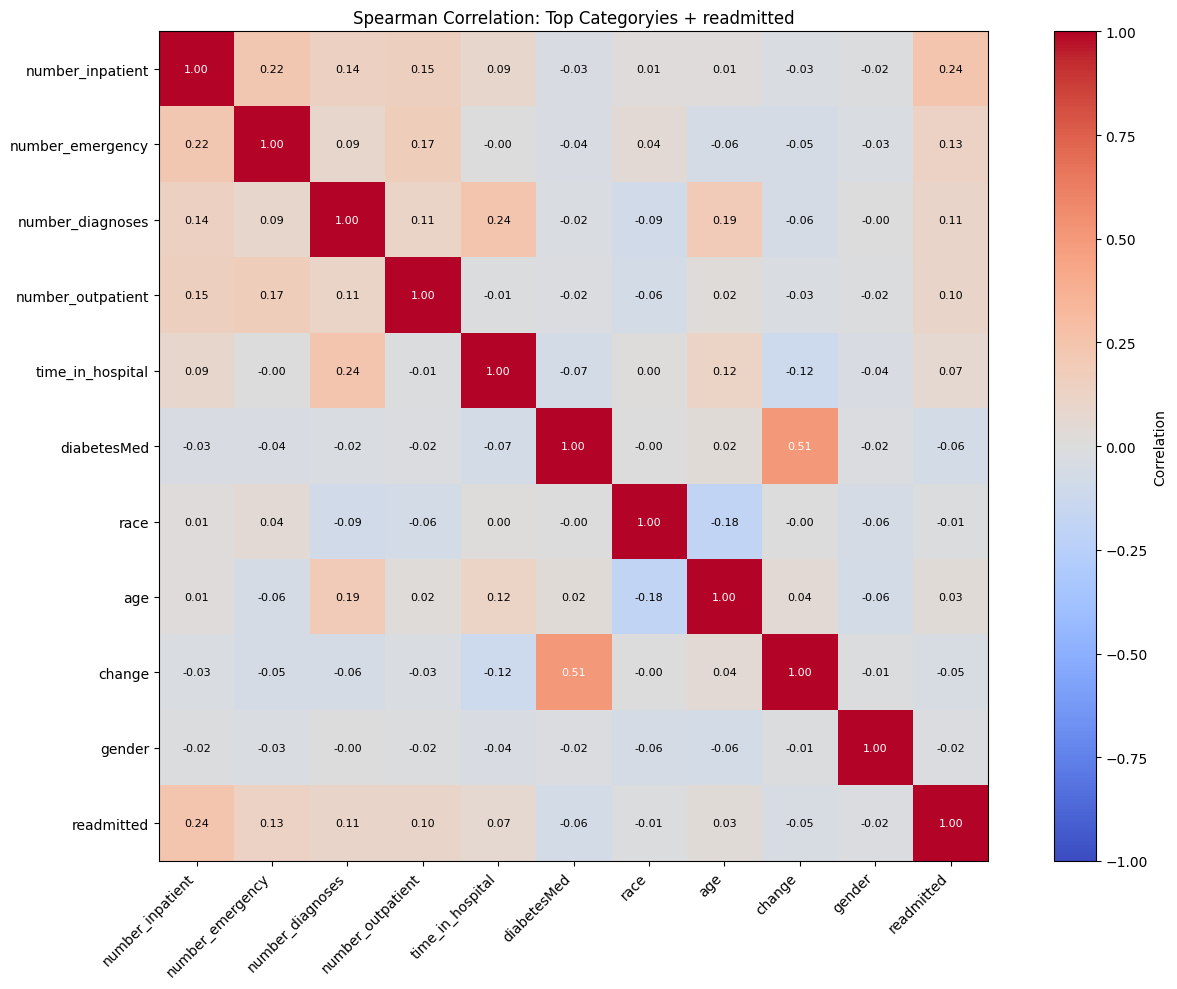

Features in graph: ['number_inpatient', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'time_in_hospital', 'diabetesMed', 'race', 'age', 'change', 'gender', 'readmitted']
Encoding used: age [0-10)=0, [10-20)=1, ...; gender Female=0, Male=1; race Caucasian=0, AfricanAmerican=1, Hispanic=2, Asian=3, Other=4
Correlation with readmitted:
readmitted           1.000000
number_inpatient     0.238223
number_emergency     0.125474
number_diagnoses     0.105370
number_outpatient    0.104701
time_in_hospital     0.065381
age                  0.025944
race                -0.013442
gender              -0.016687
change              -0.046443
diabetesMed         -0.063659


In [80]:
# Correlation heatmap for the top recommended category-like features
import matplotlib.pyplot as plt
from pandas.api.types import is_object_dtype, is_string_dtype
from pandas import CategoricalDtype

target = 'readmitted'

# Ensure _id columns are not used in this stage
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]

# Use the filtered recommendation table from the previous cell
# and explicitly include age, gender, race
top_features = rec['feature'].head(10).tolist()
top_features = [f for f in top_features if f != 'insulin']
if 'change' in raw_df.columns and 'change' not in top_features:
    top_features.append('change')
top_features = top_features[:10]

manual_features = ['age', 'gender', 'race']
selected_features = top_features + manual_features
selected_features = list(dict.fromkeys([f for f in selected_features if f in raw_df.columns and f != target and f != 'payer_code']))

plot_cols = selected_features + [target]

corr_df = raw_df[plot_cols].copy()

# Explicit mappings requested
# age: [0-10)=0, [10-20)=1, ...
age_lower = corr_df['age'].astype(str).str.extract(r'\[(\d+)-', expand=False)
corr_df['age'] = pd.to_numeric(age_lower, errors='coerce') // 10

# gender: Female=0, Male=1
gender_map = {'Female': 0, 'Male': 1}
corr_df['gender'] = corr_df['gender'].map(gender_map)

# race: White/Caucasian=0, Black/AfricanAmerican=1, Hispanic=2, Asian=3, Other=4
race_map = {
    'Caucasian': 0,
    'AfricanAmerican': 1,
    'Hispanic': 2,
    'Asian': 3,
    'Other': 4,
}
corr_df['race'] = corr_df['race'].map(race_map)

# Encode remaining categories to numeric codes for correlation
for col in corr_df.columns:
    if col in ['age', 'gender', 'race']:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
        corr_df[col] = corr_df[col].fillna(corr_df[col].median())
        continue

    if is_object_dtype(corr_df[col]) or is_string_dtype(corr_df[col]) or isinstance(corr_df[col].dtype, CategoricalDtype):
        corr_df[col] = pd.factorize(corr_df[col].fillna('__MISSING__').astype(str))[0]
    else:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
        if corr_df[col].isna().all():
            corr_df[col] = pd.factorize(raw_df[col].fillna('__MISSING__').astype(str))[0]
        else:
            corr_df[col] = corr_df[col].fillna(corr_df[col].median())

corr_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add numeric labels to each heatmap square
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(value) >= 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_color, fontsize=8)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Spearman Correlation: Top Categoryies + readmitted')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

print('Features in graph:', plot_cols)
print('Encoding used: age [0-10)=0, [10-20)=1, ...; gender Female=0, Male=1; race Caucasian=0, AfricanAmerican=1, Hispanic=2, Asian=3, Other=4')
print('Correlation with readmitted:')
print(corr_matrix['readmitted'].sort_values(ascending=False).to_string())